dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
[Timer] Data loading time: 0.00 seconds
[Timer] Interpolation time: 0.06 seconds
[Timer] Internal cross-validation time: 2.10 seconds
---- Internal Validation Metrics ----
K=10:
  MSE: 0.0030
  MAE: 0.0417
  RMSE: 0.0545
  R2: 0.3859
K=15:
  MSE: 0.0029
  MAE: 0.0414
  RMSE: 0.0540
  R2: 0.3895
K=20:
  MSE: 0.0029
  MAE: 0.0413
  RMSE: 0.0538
  R2: 0.3942


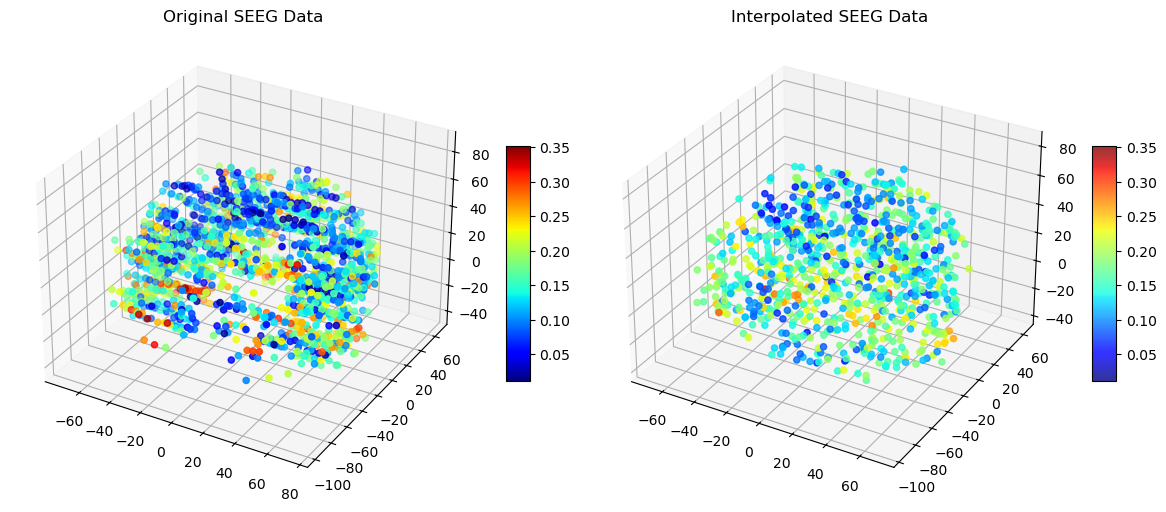

[Timer] Total runtime: 2.70 seconds


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import time  # time
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

def load_data():
    start = time.time()
    coords = np.load('coords.npy')
    band_powers = np.load('band_powers.npy', allow_pickle=True).item()
    print(band_powers.keys())
    end = time.time()
    print(f"[Timer] Data loading time: {end - start:.2f} seconds")
    return coords, band_powers

def interpolate_smooth(coords, values, method='linear'):
    start = time.time()
    grid_x = np.linspace(coords[:, 0].min(), coords[:, 0].max(), len(coords))
    grid_y = np.linspace(coords[:, 1].min(), coords[:, 1].max(), len(coords))
    grid_z = np.linspace(coords[:, 2].min(), coords[:, 2].max(), len(coords))
    
    grid_coords = np.column_stack([
        np.random.choice(grid_x, size=len(coords)),  
        np.random.choice(grid_y, size=len(coords)),  
        np.random.choice(grid_z, size=len(coords))
    ])
    
    interp_values = griddata(coords, values, grid_coords, method=method)
    end = time.time()
    print(f"[Timer] Interpolation time: {end - start:.2f} seconds")
    return grid_coords, interp_values

def calculate_metrics(true_values, pred_values):
    mask = ~np.isnan(pred_values) 
    mse = mean_squared_error(true_values[mask], pred_values[mask])
    mae = mean_absolute_error(true_values[mask], pred_values[mask])
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values[mask], pred_values[mask])
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

def cross_validate(coords, values, k_values, validation_type="Internal", band="Unknown"):
    start = time.time()
    results = {k: {"MSE": [], "MAE": [], "RMSE": [], "R2": []} for k in k_values}
    scaler = StandardScaler()
    coords = scaler.fit_transform(coords)
    
    for k in k_values:
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        for train_idx, test_idx in kf.split(coords):
            train_coords, test_coords = coords[train_idx], coords[test_idx]
            train_values, test_values = values[train_idx], values[test_idx]
            pred_values = griddata(train_coords, train_values, test_coords, method='linear')
            metrics = calculate_metrics(test_values, pred_values)
            for metric in results[k]:
                results[k][metric].append(metrics[metric])
    end = time.time()
    print(f"[Timer] {validation_type} cross-validation time: {end - start:.2f} seconds")
    return results

def print_metrics(metrics_results, evaluation_type):
    print(f"---- {evaluation_type} Validation Metrics ----")
    for k, metrics in metrics_results.items():
        print(f"K={k}:")
        for metric_name, values in metrics.items():
            avg_value = np.mean(values)
            print(f"  {metric_name}: {avg_value:.4f}")

def main():
    total_start = time.time()  # <-- time start
    
    coords, band_powers = load_data()
    band = 'Delta' 
    if band not in band_powers:
        print(f"Band {band} not found in data.")
        return
    
    band_values = np.array(band_powers[band])
    interp_coords, interp_values = interpolate_smooth(coords, band_values, method='linear')
    
    k_values = [10, 15, 20]
    internal_metrics = cross_validate(coords, band_values, k_values, validation_type="Internal", band=band)
    # external_metrics = cross_validate(interp_coords, interp_values, k_values, validation_type="External", band=band)
    
    print_metrics(internal_metrics, "Internal")
    # print_metrics(external_metrics, "External")
    
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    scatter1 = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=band_values, cmap='jet', marker='o')
    ax1.set_title("Original SEEG Data")

    vmin = np.min([band_values.min(), band_values.min()])
    vmax = np.max([band_values.max(), band_values.max()])
    scatter1.set_clim(vmin=vmin, vmax=vmax)
    fig.colorbar(scatter1, ax=ax1, shrink=0.5, aspect=10)
    
    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(interp_coords[:, 0], interp_coords[:, 1], interp_coords[:, 2], c=interp_values, cmap='jet', marker='o', alpha=0.8)
    ax2.set_title("Interpolated SEEG Data")
    scatter2.set_clim(vmin=vmin, vmax=vmax)
    fig.colorbar(scatter2, ax=ax2, shrink=0.5, aspect=10)

    plt.tight_layout()
    plt.show()
    
    total_end = time.time()  # <-- time end
    print(f"[Timer] Total runtime: {total_end - total_start:.2f} seconds")
    
if __name__ == "__main__":
    main()



--- Timing Summary ---
RBF Interpolation total time:     1.33 seconds
Linear Interpolation total time:  0.53 seconds
Nearest Interpolation total time: 0.01 seconds
KNN Interpolation total time:     0.15 seconds
Total execution time:             2.25 seconds


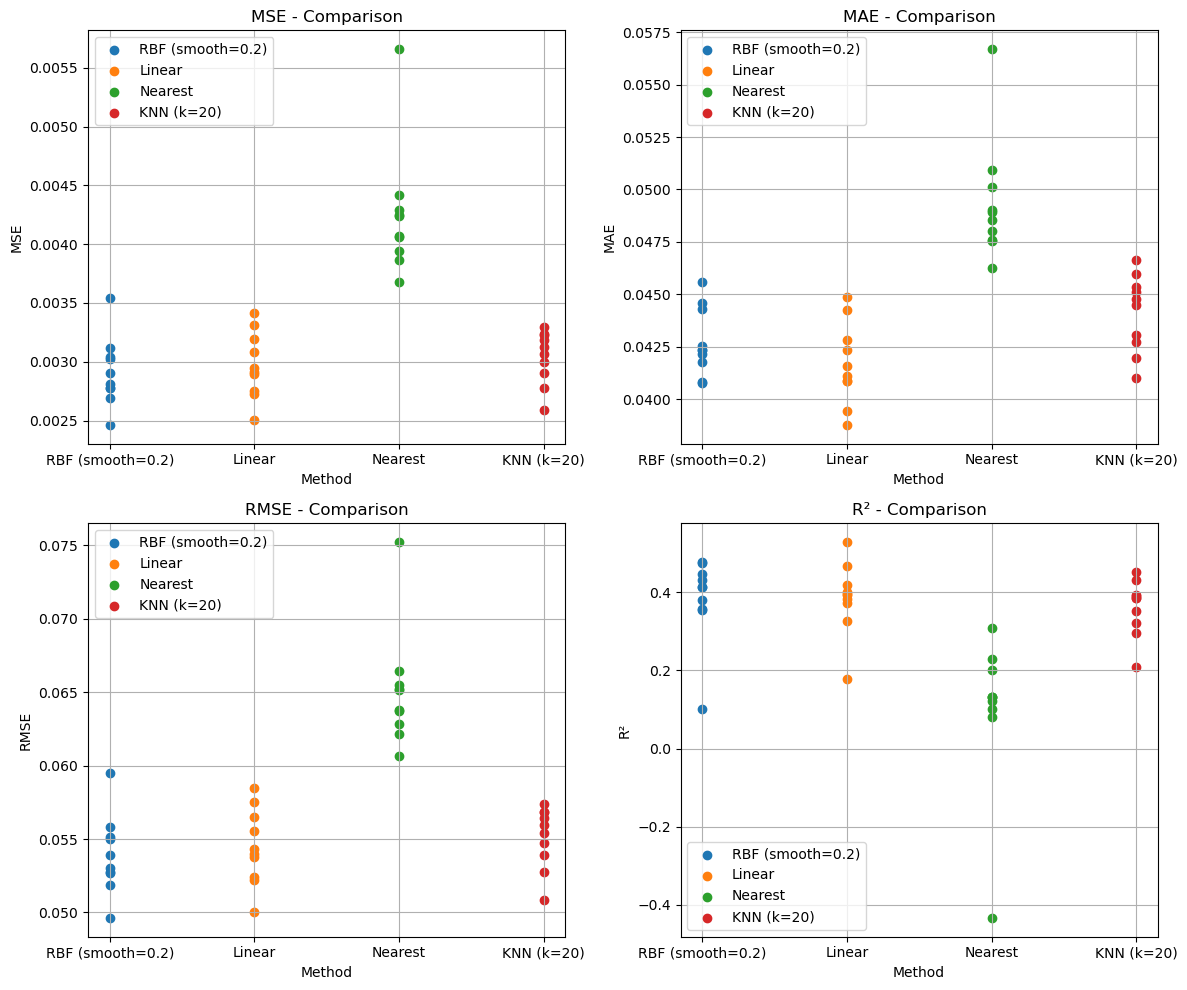

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.interpolate import Rbf, griddata
from math import sqrt
from sklearn.preprocessing import StandardScaler
import time  #time

# Start total timer
total_start = time.time()

# Load the data
coords = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

# Choose which frequency band to evaluate
band = 'Delta'
values = np.array(band_powers[band])

# Normalize coordinates to avoid ill-conditioned matrix issues
scaler = StandardScaler()
coords_normalized = scaler.fit_transform(coords)

# Define RBF Interpolation Function with adjustable smoothness
def interpolate_rbf(coords, values, new_coords, smooth_value=0.2):
    rbf = Rbf(coords[:, 0], coords[:, 1], coords[:, 2], values, function='multiquadric', smooth=smooth_value)
    return rbf(new_coords[:, 0], new_coords[:, 1], new_coords[:, 2])

# Define Linear Interpolation Function
def interpolate_linear(coords, values, new_coords):
    return griddata(coords, values, new_coords, method='linear')

# Define Nearest Interpolation Function
def interpolate_nearest(coords, values, new_coords):
    return griddata(coords, values, new_coords, method='nearest')

# Define KNN Interpolation Function (k=20)
def interpolate_knn(coords, values, new_coords, k=20):
    from sklearn.neighbors import KNeighborsRegressor
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(coords, values)
    return knn.predict(new_coords)

# Define Metric Calculation Function
def calculate_metrics(pred_values, test_values):
    return {
        'MSE': mean_squared_error(test_values, pred_values),
        'MAE': mean_absolute_error(test_values, pred_values),
        'RMSE': sqrt(mean_squared_error(test_values, pred_values)),
        'R²': r2_score(test_values, pred_values)
    }

# Set up cross-validation
num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialise arrays to store results
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
rbf_results = np.zeros((num_folds, len(metrics)))
linear_results = np.zeros((num_folds, len(metrics)))
nearest_results = np.zeros((num_folds, len(metrics)))
knn_results = np.zeros((num_folds, len(metrics)))

# Timers for each interpolation method
time_rbf = 0
time_linear = 0
time_nearest = 0
time_knn = 0

# Cross-validation for each method
for i, (train_index, test_index) in enumerate(kf.split(coords_normalized)):
    train_coords, test_coords = coords_normalized[train_index], coords_normalized[test_index]
    train_values, test_values = values[train_index], values[test_index]
    
    # RBF Interpolation
    start = time.time()
    pred_values = interpolate_rbf(train_coords, train_values, test_coords, smooth_value=0.2)
    time_rbf += time.time() - start
    valid_indices = ~np.isnan(pred_values)
    rbf_results[i] = [calculate_metrics(pred_values[valid_indices], test_values[valid_indices])[m] for m in metrics]
    
    # Linear Interpolation
    start = time.time()
    pred_values = interpolate_linear(train_coords, train_values, test_coords)
    time_linear += time.time() - start
    valid_indices = ~np.isnan(pred_values)
    linear_results[i] = [calculate_metrics(pred_values[valid_indices], test_values[valid_indices])[m] for m in metrics]
    
    # Nearest Interpolation
    start = time.time()
    pred_values = interpolate_nearest(train_coords, train_values, test_coords)
    time_nearest += time.time() - start
    valid_indices = ~np.isnan(pred_values)
    nearest_results[i] = [calculate_metrics(pred_values[valid_indices], test_values[valid_indices])[m] for m in metrics]
    
    # KNN Interpolation (k=20)
    start = time.time()
    pred_values = interpolate_knn(train_coords, train_values, test_coords, k=20)
    time_knn += time.time() - start
    knn_results[i] = [calculate_metrics(pred_values, test_values)[m] for m in metrics]

# Print timing results
print("\n--- Timing Summary ---")
print(f"RBF Interpolation total time:     {time_rbf:.2f} seconds")
print(f"Linear Interpolation total time:  {time_linear:.2f} seconds")
print(f"Nearest Interpolation total time: {time_nearest:.2f} seconds")
print(f"KNN Interpolation total time:     {time_knn:.2f} seconds")
print(f"Total execution time:             {time.time() - total_start:.2f} seconds")

# Create a 2x2 grid for the scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

methods = ['RBF (smooth=0.2)', 'Linear', 'Nearest', 'KNN (k=20)']
results = [rbf_results, linear_results, nearest_results, knn_results]

for i, metric in enumerate(metrics):
    for method, result in zip(methods, results):
        axes[i].scatter([method] * num_folds, result[:, i], label=method)
    
    axes[i].set_title(f'{metric} - Comparison')
    axes[i].set_xlabel('Method')
    axes[i].set_ylabel(metric)
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()


This code uses four different interpolation methods (RBF, linear, nearest neighbor, KNN) to evaluate the accuracy of data interpolation, and uses 10-fold cross validation for error analysis. The results show that RBF interpolation can provide lower mean square error (MSE) and higher coefficient of determination (R²) when smoothness is good, but its performance depends on the choice of smoothing parameters. Linear interpolation is generally stable, but may cause large errors in areas with sparse data. Nearest neighbor interpolation is relatively fast, but may produce large errors, especially in rapidly changing data distributions. KNN interpolation (based on K=20) works better when the data is dense locally, but may have large deviations when the data distribution is uneven. Overall, the suitability of different methods depends on the characteristics of the data, and the KNN methods provide a certain compromise between smoothness and accuracy.

dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
[Timer] Data loading time: 0.00 seconds
[Timer] Starting cross-validation with K=10
[Timer] K=10 cross-validation time: 0.47 seconds
[Timer] Starting cross-validation with K=15
[Timer] K=15 cross-validation time: 0.68 seconds
[Timer] Starting cross-validation with K=20
[Timer] K=20 cross-validation time: 0.93 seconds
[Timer] Total cross-validation time: 2.08 seconds


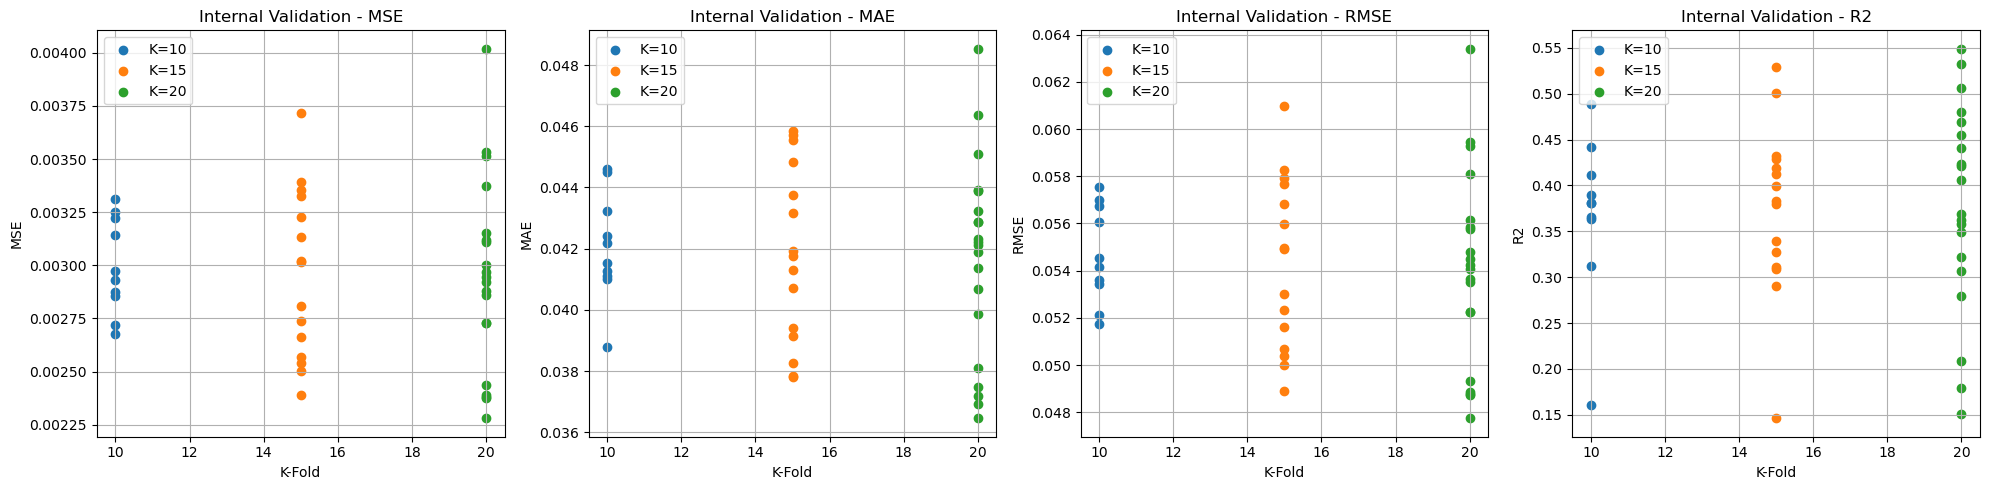

[Timer] Total program runtime: 2.90 seconds


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import time  # Import time module

def load_data():
    start = time.time()
    coords = np.load('coords.npy')
    band_powers = np.load('band_powers.npy', allow_pickle=True).item()
    print(band_powers.keys())
    end = time.time()
    print(f"[Timer] Data loading time: {end - start:.2f} seconds")
    return coords, band_powers

def calculate_metrics(true_values, pred_values):
    mask = ~np.isnan(pred_values)
    if np.sum(mask) == 0:
        return None
    mse = mean_squared_error(true_values[mask], pred_values[mask])
    mae = mean_absolute_error(true_values[mask], pred_values[mask])
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values[mask], pred_values[mask])
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

def cross_validate_internal(coords, values, k_values):
    overall_start = time.time()
    results = {k: {"MSE": [], "MAE": [], "RMSE": [], "R2": []} for k in k_values}
    scaler = StandardScaler()
    coords = scaler.fit_transform(coords)

    for k in k_values:
        print(f"[Timer] Starting cross-validation with K={k}")
        k_start = time.time()

        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        for train_idx, test_idx in kf.split(coords):
            train_coords, test_coords = coords[train_idx], coords[test_idx]
            train_values, test_values = values[train_idx], values[test_idx]
            pred_values = griddata(train_coords, train_values, test_coords, method='linear')
            pred_values = np.nan_to_num(pred_values, nan=np.mean(train_values))

            metrics = calculate_metrics(test_values, pred_values)
            if metrics is None:
                continue

            for metric in results[k]:
                results[k][metric].append(metrics[metric])

        k_end = time.time()
        print(f"[Timer] K={k} cross-validation time: {k_end - k_start:.2f} seconds")

    overall_end = time.time()
    print(f"[Timer] Total cross-validation time: {overall_end - overall_start:.2f} seconds")
    return results

def plot_internal_metrics(internal_metrics, k_values):
    metrics = ["MSE", "MAE", "RMSE", "R2"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for i, metric in enumerate(metrics):
        for k in k_values:
            axes[i].scatter([k] * len(internal_metrics[k][metric]), internal_metrics[k][metric], label=f'K={k}')
        axes[i].set_title(f"Internal Validation - {metric}")
        axes[i].set_ylabel(metric)
        axes[i].set_xlabel("K-Fold")
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

def main():
    total_start = time.time()

    coords, band_powers = load_data()
    band = 'Delta'
    if band not in band_powers:
        print(f"Band {band} not found in data.")
        return

    band_values = np.array(band_powers[band])
    k_values = [10, 15, 20]
    internal_metrics = cross_validate_internal(coords, band_values, k_values)
    plot_internal_metrics(internal_metrics, k_values)

    total_end = time.time()
    print(f"[Timer] Total program runtime: {total_end - total_start:.2f} seconds")

if __name__ == "__main__":
    main()



--- Timing Summary ---
RBF interpolation time:     3.38 seconds
Linear interpolation time:  1.45 seconds
Nearest interpolation time: 0.02 seconds
KNN interpolation time:     0.05 seconds
Total runtime:              5.45 seconds


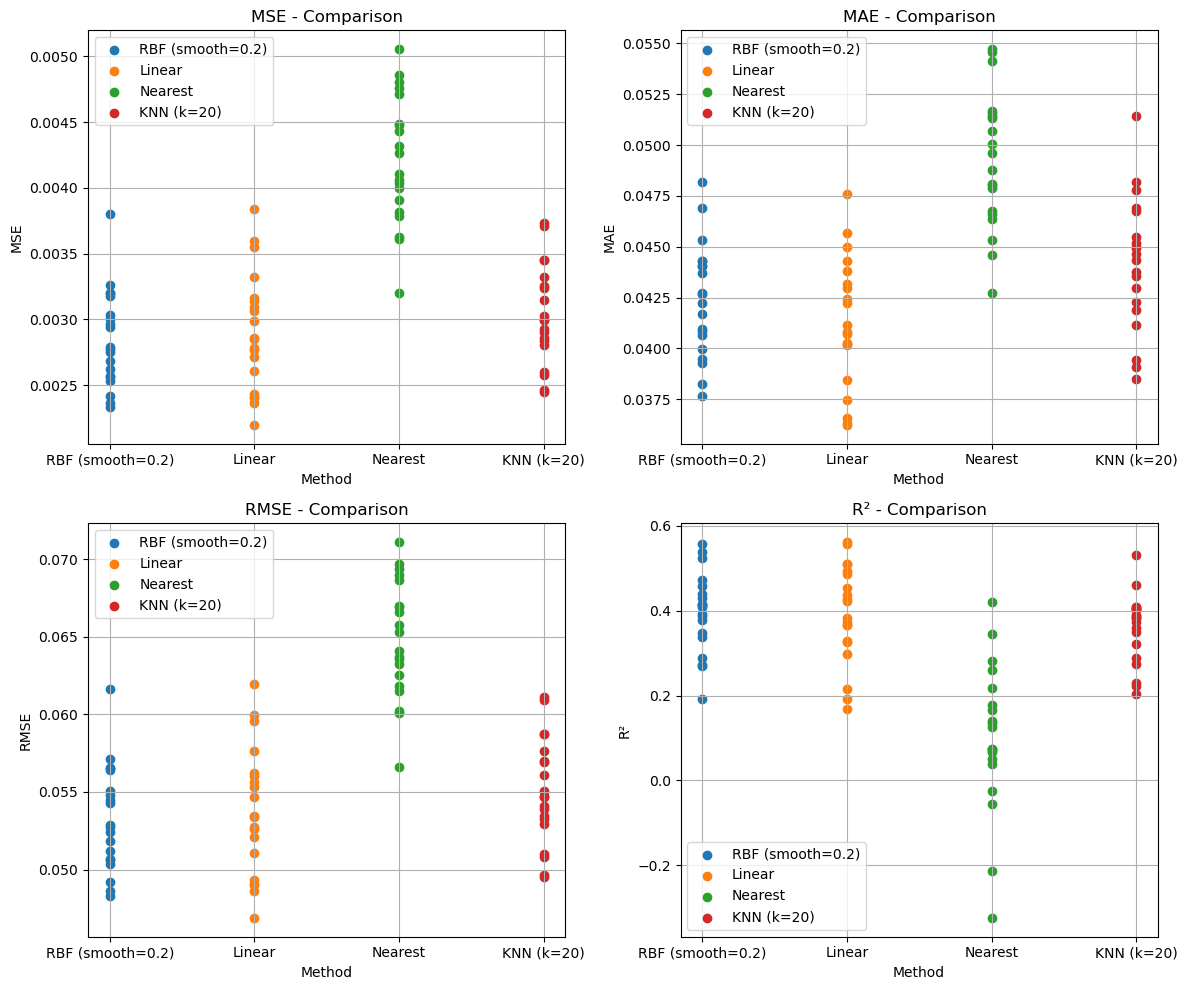

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.interpolate import Rbf, griddata
from math import sqrt
from sklearn.preprocessing import StandardScaler
import time  # Import time module

# Start total timer
total_start = time.time()

# Load the data
coords = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

# Choose which frequency band to evaluate
band = 'Delta'
values = np.array(band_powers[band])

# Normalize coordinates to avoid ill-conditioned matrix issues
scaler = StandardScaler()
coords_normalized = scaler.fit_transform(coords)

# Define RBF Interpolation Function with adjustable smoothness
def interpolate_rbf(coords, values, new_coords, smooth_value=0.2):
    rbf = Rbf(coords[:, 0], coords[:, 1], coords[:, 2], values, function='multiquadric', smooth=smooth_value)
    return rbf(new_coords[:, 0], new_coords[:, 1], new_coords[:, 2])

# Define Linear Interpolation Function
def interpolate_linear(coords, values, new_coords):
    return griddata(coords, values, new_coords, method='linear')

# Define Nearest Interpolation Function
def interpolate_nearest(coords, values, new_coords):
    return griddata(coords, values, new_coords, method='nearest')

# Define KNN Interpolation Function (k=20)
def interpolate_knn(coords, values, new_coords, k=20):
    from sklearn.neighbors import KNeighborsRegressor
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(coords, values)
    return knn.predict(new_coords)

# Define Metric Calculation Function
def calculate_metrics(pred_values, test_values):
    return {
        'MSE': mean_squared_error(test_values, pred_values),
        'MAE': mean_absolute_error(test_values, pred_values),
        'RMSE': sqrt(mean_squared_error(test_values, pred_values)),
        'R²': r2_score(test_values, pred_values)
    }

# Set up cross-validation with 20 folds
num_folds = 20
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialise arrays to store results
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
rbf_results = np.zeros((num_folds, len(metrics)))
linear_results = np.zeros((num_folds, len(metrics)))
nearest_results = np.zeros((num_folds, len(metrics)))
knn_results = np.zeros((num_folds, len(metrics)))

# Timers for each interpolation method
rbf_time = 0
linear_time = 0
nearest_time = 0
knn_time = 0

# Cross-validation for each method
for i, (train_index, test_index) in enumerate(kf.split(coords_normalized)):
    train_coords, test_coords = coords_normalized[train_index], coords_normalized[test_index]
    train_values, test_values = values[train_index], values[test_index]
    
    # RBF Interpolation
    start = time.time()
    pred_values = interpolate_rbf(train_coords, train_values, test_coords, smooth_value=0.2)
    rbf_time += time.time() - start
    valid_indices = ~np.isnan(pred_values)
    rbf_results[i] = [calculate_metrics(pred_values[valid_indices], test_values[valid_indices])[m] for m in metrics]
    
    # Linear Interpolation
    start = time.time()
    pred_values = interpolate_linear(train_coords, train_values, test_coords)
    linear_time += time.time() - start
    valid_indices = ~np.isnan(pred_values)
    linear_results[i] = [calculate_metrics(pred_values[valid_indices], test_values[valid_indices])[m] for m in metrics]
    
    # Nearest Interpolation
    start = time.time()
    pred_values = interpolate_nearest(train_coords, train_values, test_coords)
    nearest_time += time.time() - start
    valid_indices = ~np.isnan(pred_values)
    nearest_results[i] = [calculate_metrics(pred_values[valid_indices], test_values[valid_indices])[m] for m in metrics]
    
    # KNN Interpolation (k=20)
    start = time.time()
    pred_values = interpolate_knn(train_coords, train_values, test_coords, k=20)
    knn_time += time.time() - start
    knn_results[i] = [calculate_metrics(pred_values, test_values)[m] for m in metrics]

# Print timing summary
print("\n--- Timing Summary ---")
print(f"RBF interpolation time:     {rbf_time:.2f} seconds")
print(f"Linear interpolation time:  {linear_time:.2f} seconds")
print(f"Nearest interpolation time: {nearest_time:.2f} seconds")
print(f"KNN interpolation time:     {knn_time:.2f} seconds")
print(f"Total runtime:              {time.time() - total_start:.2f} seconds")

# Create a 2x2 grid for the scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

methods = ['RBF (smooth=0.2)', 'Linear', 'Nearest', 'KNN (k=20)']
results = [rbf_results, linear_results, nearest_results, knn_results]

for i, metric in enumerate(metrics):
    for method, result in zip(methods, results):
        axes[i].scatter([method] * num_folds, result[:, i], label=method)
    
    axes[i].set_title(f'{metric} - Comparison')
    axes[i].set_xlabel('Method')
    axes[i].set_ylabel(metric)
    axes[i].grid(True)
    axes[i].legend()

# Adjust layout
plt.tight_layout()
plt.show()
